# Most active users

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load the dataset
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

In [3]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='str')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",NaN,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",NaN,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,NaN,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


## Most Active Users

In [4]:
# Rank users by message count
user_message_counts = df['sender_id'].value_counts()
print(user_message_counts.head(10))

sender_id
1762777403    441
7094531229    432
1505404600    388
271855505     347
6973904485    339
6601816159    298
6221273187    278
1095473116    237
5689570195    232
1151037126    230
Name: count, dtype: int64


A lo mejor debería anonimizar los datos.

In [5]:
# total number of messages
total_messages = len(df)
print(f"Total number of messages: {total_messages}")

# number of unique users
unique_users = df['sender_id'].nunique()
print(f"Number of unique users: {unique_users}")

# average messages per user
average_messages_per_user = total_messages / unique_users
print(f"Average messages per user: {average_messages_per_user:.2f}")

# Users with no messages (if any)
users_with_no_messages = unique_users - user_message_counts.count()
print(f"Number of users with no messages: {users_with_no_messages}")

# Users with more than 100 messages
users_with_more_than_100_messages = user_message_counts[user_message_counts > 100].count()
print(f"Number of users with more than 100 messages: {users_with_more_than_100_messages}")




Total number of messages: 18064
Number of unique users: 2539
Average messages per user: 7.11
Number of users with no messages: 0
Number of users with more than 100 messages: 26


### Most active users before 2025

In [6]:
df_2024 = df[df['date'].dt.year == 2024]

In [7]:
# Rank users by message count
user_message_counts = df_2024['sender_id'].value_counts()
print(user_message_counts.head(10))

sender_id
1762777403    441
7094531229    412
1505404600    388
6973904485    339
271855505     321
6601816159    298
6221273187    278
1095473116    237
1151037126    230
1457424889    226
Name: count, dtype: int64


In [8]:
# total number of messages
total_messages_2024 = len(df_2024)
print(f"Total number of messages: {total_messages_2024}")

# number of unique users
unique_users_2024 = df_2024['sender_id'].nunique()
print(f"Number of unique users: {unique_users_2024}")

# average messages per user
average_messages_per_user_2024 = total_messages_2024 / unique_users_2024
print(f"Average messages per user: {average_messages_per_user_2024:.2f}")

# Users with no messages (if any)
users_with_no_messages = unique_users_2024 - user_message_counts.count()
print(f"Number of users with no messages: {users_with_no_messages}")

# Users with more than 100 messages
users_with_more_than_100_messages = user_message_counts[user_message_counts > 100].count()
print(f"Number of users with more than 100 messages: {users_with_more_than_100_messages}")




Total number of messages: 17044
Number of unique users: 2417
Average messages per user: 7.05
Number of users with no messages: 0
Number of users with more than 100 messages: 24


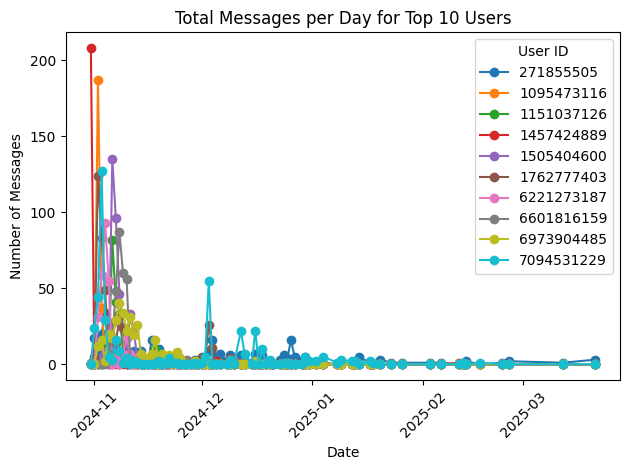

In [9]:
# Plot total messages per day per user for the top 10 users
top_users = user_message_counts.head(10).index
top_users_data = df[df['sender_id'].isin(top_users)]
top_users_data['date'] = top_users_data['date'].dt.date
messages_per_day = top_users_data.groupby(['date', 'sender_id']).size().unstack(fill_value=0)
messages_per_day.plot(kind='line', marker='o')
plt.title('Total Messages per Day for Top 10 Users')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.legend(title='User ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Users per Channel

In [10]:
# Generate dataframe for each channel
df_general = df[df['topic_name'] == 'Discusión general']
df_bienvenidos = df[df['topic_name'] == 'Bienvenid@s a la Red de Voluntari@s (leed primero)']
df_tranporte = df[df['topic_name'] == 'Transporte de personas a Comunidad Valenciana']
df_grupos_accion = df[df['topic_name'] == 'Grupos de Acción Voluntarios en Terreno']
df_juridica = df[df['topic_name'] == 'Asistencia Jurídica/Seguros']
df_tecnica = df[df['topic_name'] == 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)']
df_animales = df[df['topic_name'] == 'Asistencia animales compañia y otros']
df_informatica = df[df['topic_name'] == 'Asistencia Informática/Soporte EAT']
df_logistica = df[df['topic_name'] == 'Logística Interna Valencia(puntos de recepción)']
df_ayudaempresas = df[df['topic_name'] == 'Ayuda de Empresas']
df_investigacion = df[df['topic_name'] == 'Investigación Ciudadana: Responsabilidades Políticas']
df_asistencia_voluntarios = df[df['topic_name'] == 'Asistencia a Voluntarios (Comida y Acogida))']
df_asistencia_vulnerables = df[df['topic_name'] == 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)']
df_material = df[df['topic_name'] == 'Material Video/Fotográfico']
df_webs = df[df['topic_name'] == 'Webs Esenciales']
df_mensajes_ayuda = df[df['topic_name'] == 'Mensajes de Ayuda (Ofrezco/Necesito)']
df_voluntarios_fuera = df[df['topic_name'] == 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)']
df_viviendas = df[df['topic_name'] == 'Viviendas Edificación , Muebles y Acondicionamiento']


In [11]:
# Top 10 users per channel
top_users_general = df_general['sender_id'].value_counts().head(10)
top_users_bienvenidos = df_bienvenidos['sender_id'].value_counts().head(10)
top_users_tranporte = df_tranporte['sender_id'].value_counts().head(10)
top_users_grupos_accion = df_grupos_accion['sender_id'].value_counts().head(10)
top_users_juridica = df_juridica['sender_id'].value_counts().head(10)
top_users_tecnica = df_tecnica['sender_id'].value_counts().head(10)
top_users_animales = df_animales['sender_id'].value_counts().head(10)
top_users_informatica = df_informatica['sender_id'].value_counts().head(10)
top_users_logistica = df_logistica['sender_id'].value_counts().head(10)
top_users_ayudaempresas = df_ayudaempresas['sender_id'].value_counts().head(10)
top_users_investigacion = df_investigacion['sender_id'].value_counts().head(10)
top_users_asistencia_voluntarios = df_asistencia_voluntarios['sender_id'].value_counts().head(10)
top_users_asistencia_vulnerables = df_asistencia_vulnerables['sender_id'].value_counts().head(10)
top_users_material = df_material['sender_id'].value_counts().head(10)
top_users_webs = df_webs['sender_id'].value_counts().head(10)
top_users_mensajes_ayuda = df_mensajes_ayuda['sender_id'].value_counts().head(10)
top_users_voluntarios_fuera = df_voluntarios_fuera['sender_id'].value_counts().head(10)
top_users_viviendas = df_viviendas['sender_id'].value_counts().head(10)

# Show top users for each channel and their message counts
print("Top 10 users in General Discussion:")
print(top_users_general)
print("\nTop 10 users in Bienvenidos:")
print(top_users_bienvenidos)
print("\nTop 10 users in Transporte:")
print(top_users_tranporte)
print("\nTop 10 users in Grupos de Acción:")
print(top_users_grupos_accion)
print("\nTop 10 users in Asistencia Jurídica/Seguros:")
print(top_users_juridica)
print("\nTop 10 users in Asistencia Técnica y Maquinaria:")
print(top_users_tecnica)
print("\nTop 10 users in Asistencia animales compañia y otros:")
print(top_users_animales)
print("\nTop 10 users in Asistencia Informática/Soporte EAT:")
print(top_users_informatica)
print("\nTop 10 users in Logística Interna Valencia:")
print(top_users_logistica)
print("\nTop 10 users in Ayuda de Empresas:")
print(top_users_ayudaempresas)
print("\nTop 10 users in Investigación Ciudadana:")
print(top_users_investigacion)
print("\nTop 10 users in Asistencia a Voluntarios:")
print(top_users_asistencia_voluntarios)
print("\nTop 10 users in Asistencia a Vulnerables:")
print(top_users_asistencia_vulnerables)
print("\nTop 10 users in Material Video/Fotográfico:")
print(top_users_material)
print("\nTop 10 users in Webs Esenciales:")
print(top_users_webs)
print("\nTop 10 users in Mensajes de Ayuda:")
print(top_users_mensajes_ayuda)
print("\nTop 10 users in Voluntarios de fuera de Valencia:")
print(top_users_voluntarios_fuera)
print("\nTop 10 users in Viviendas Edificación , Muebles y Acondicionamiento:")
print(top_users_viviendas)


Top 10 users in General Discussion:
sender_id
1110241832    55
941865373     15
1762777403    13
1551829597    12
1662351336    12
5919794964    11
602365744      9
6618601093     8
5501326376     7
5229698385     5
Name: count, dtype: int64

Top 10 users in Bienvenidos:
sender_id
6221273187    87
6601816159    59
5689570195    42
1101084020    35
709835653     31
305217439     29
6743180623    29
5992929865    27
7861477170    24
1093909522    24
Name: count, dtype: int64

Top 10 users in Transporte:
sender_id
1457424889    207
5229698385     65
7472715818     49
5197641355     31
5689570195     27
6929535140     24
524281487      24
1304166575     23
5879036548     22
702737014      20
Name: count, dtype: int64

Top 10 users in Grupos de Acción:
sender_id
693274644     93
6221273187    57
6601816159    47
1131058651    42
5689570195    32
8144868265    29
5992929865    23
1110241832    22
361288190     16
6973904485    13
Name: count, dtype: int64

Top 10 users in Asistencia Jurídica

### Cross-channel overlap of top users
This section shows which users appear in the top 10 across multiple channels.

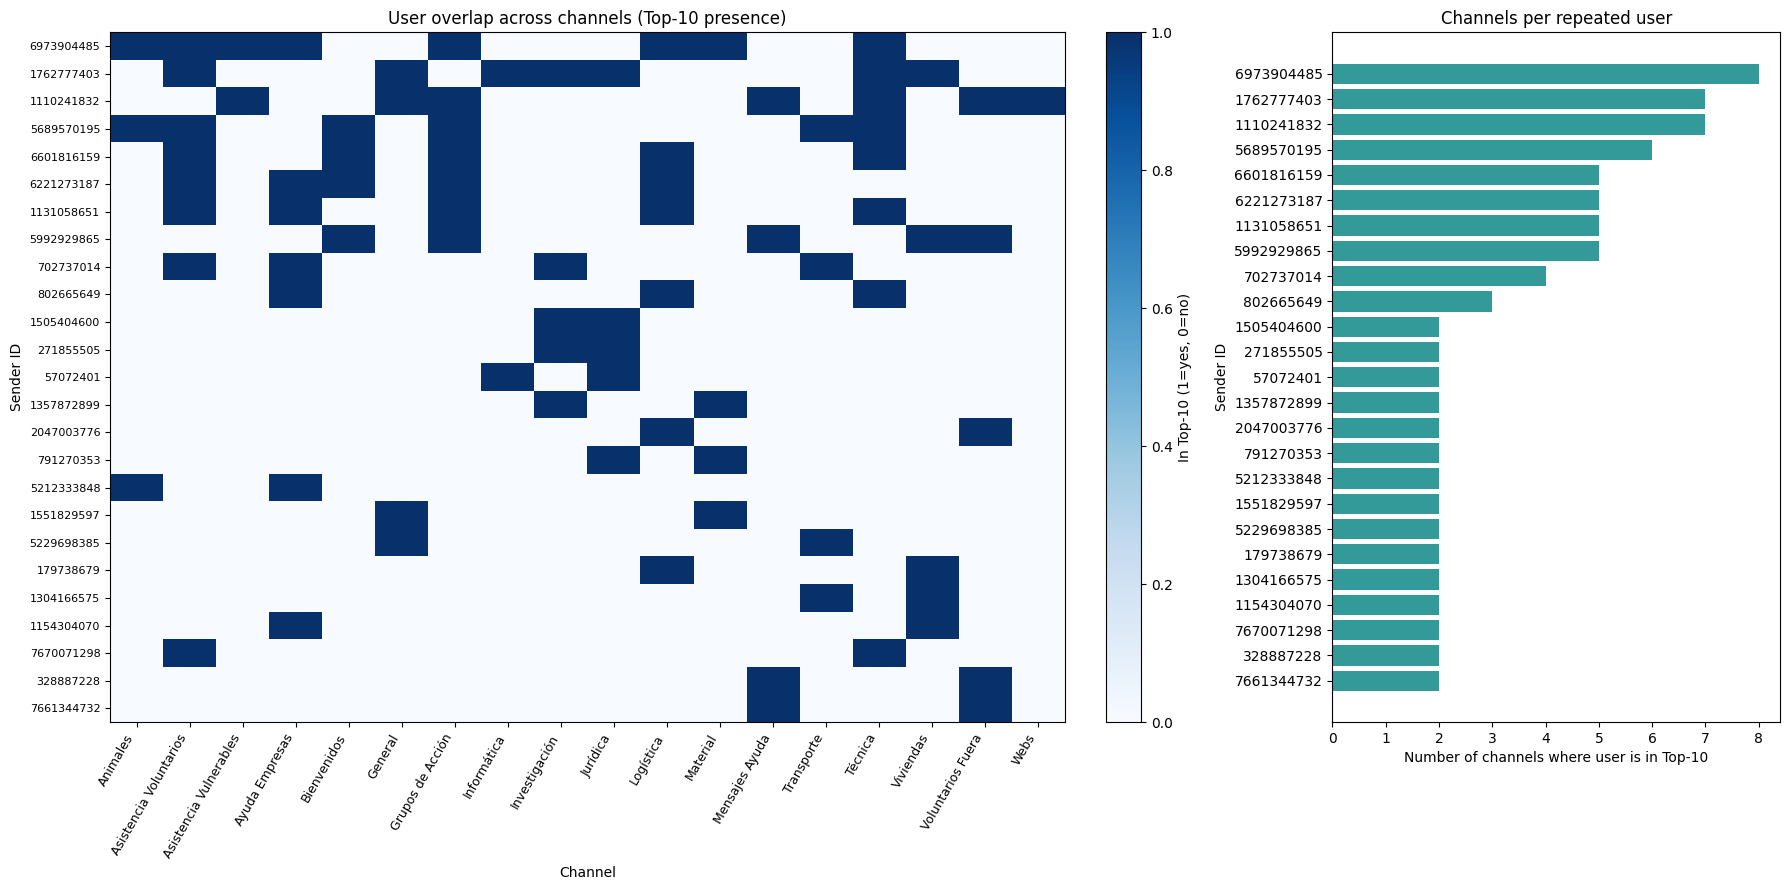

Top repeated users (first 15):


,n_channels,total_top10_msgs
sender_id,,
6973904485,8,256
1762777403,7,363
1110241832,7,117
5689570195,6,192
6601816159,5,284
6221273187,5,235
1131058651,5,109
5992929865,5,84
702737014,4,148


In [12]:
# Build a unified table of top-10 users across channels and visualize overlap
channel_top_users = {
    'General': top_users_general,
    'Bienvenidos': top_users_bienvenidos,
    'Transporte': top_users_tranporte,
    'Grupos de Acción': top_users_grupos_accion,
    'Jurídica': top_users_juridica,
    'Técnica': top_users_tecnica,
    'Animales': top_users_animales,
    'Informática': top_users_informatica,
    'Logística': top_users_logistica,
    'Ayuda Empresas': top_users_ayudaempresas,
    'Investigación': top_users_investigacion,
    'Asistencia Voluntarios': top_users_asistencia_voluntarios,
    'Asistencia Vulnerables': top_users_asistencia_vulnerables,
    'Material': top_users_material,
    'Webs': top_users_webs,
    'Mensajes Ayuda': top_users_mensajes_ayuda,
    'Voluntarios Fuera': top_users_voluntarios_fuera,
    'Viviendas': top_users_viviendas,
}

records = []
for channel, series in channel_top_users.items():
    for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
        records.append({
            'channel': channel,
            'sender_id': int(sender_id),
            'rank': rank,
            'msg_count': int(msg_count)
        })

top_users_long = pd.DataFrame(records)

# Presence matrix: 1 if user is in top-10 for that channel, else 0
presence = (
    top_users_long.assign(in_top10=1)
    .pivot_table(index='sender_id', columns='channel', values='in_top10', aggfunc='max', fill_value=0)
    .astype(int)
)

# User-level summary to sort by overlap strength
user_summary = (
    top_users_long.groupby('sender_id', as_index=True)
    .agg(n_channels=('channel', 'nunique'), total_top10_msgs=('msg_count', 'sum'))
    .sort_values(['n_channels', 'total_top10_msgs'], ascending=[False, False])
)

presence = presence.loc[user_summary.index]

# Keep users that appear in at least 2 channels for readability
presence_multi = presence.loc[user_summary['n_channels'] >= 2]
summary_multi = user_summary.loc[user_summary['n_channels'] >= 2]

if presence_multi.empty:
    print('No users appear in top-10 of more than one channel.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), gridspec_kw={'width_ratios': [2.8, 1.2]})

    # Heatmap of cross-channel presence
    im = axes[0].imshow(presence_multi.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('User overlap across channels (Top-10 presence)')
    axes[0].set_xlabel('Channel')
    axes[0].set_ylabel('Sender ID')
    axes[0].set_xticks(np.arange(presence_multi.shape[1]))
    axes[0].set_xticklabels(presence_multi.columns, rotation=60, ha='right', fontsize=9)
    axes[0].set_yticks(np.arange(presence_multi.shape[0]))
    axes[0].set_yticklabels([str(u) for u in presence_multi.index], fontsize=8)
    cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label('In Top-10 (1=yes, 0=no)')

    # Bar chart: number of channels per repeated user
    axes[1].barh(
        [str(u) for u in summary_multi.index[::-1]],
        summary_multi['n_channels'].values[::-1],
        color='teal',
        alpha=0.8
    )
    axes[1].set_title('Channels per repeated user')
    axes[1].set_xlabel('Number of channels where user is in Top-10')
    axes[1].set_ylabel('Sender ID')

    plt.tight_layout()
    plt.show()

    print('Top repeated users (first 15):')
    display(summary_multi.head(15))

### Sorted channels by similarity + user-channel network
This view clusters channels with similar top-10 user composition and shows a bipartite network of repeated users vs channels.

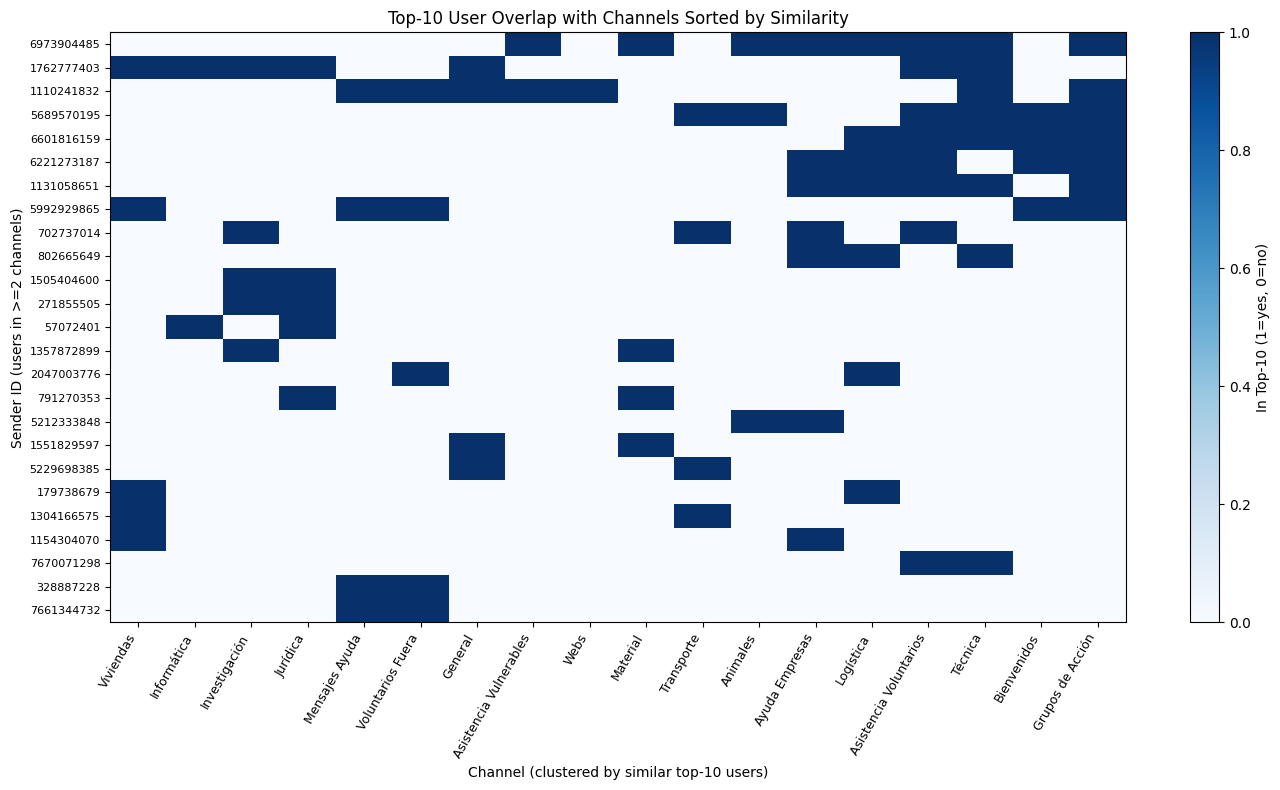

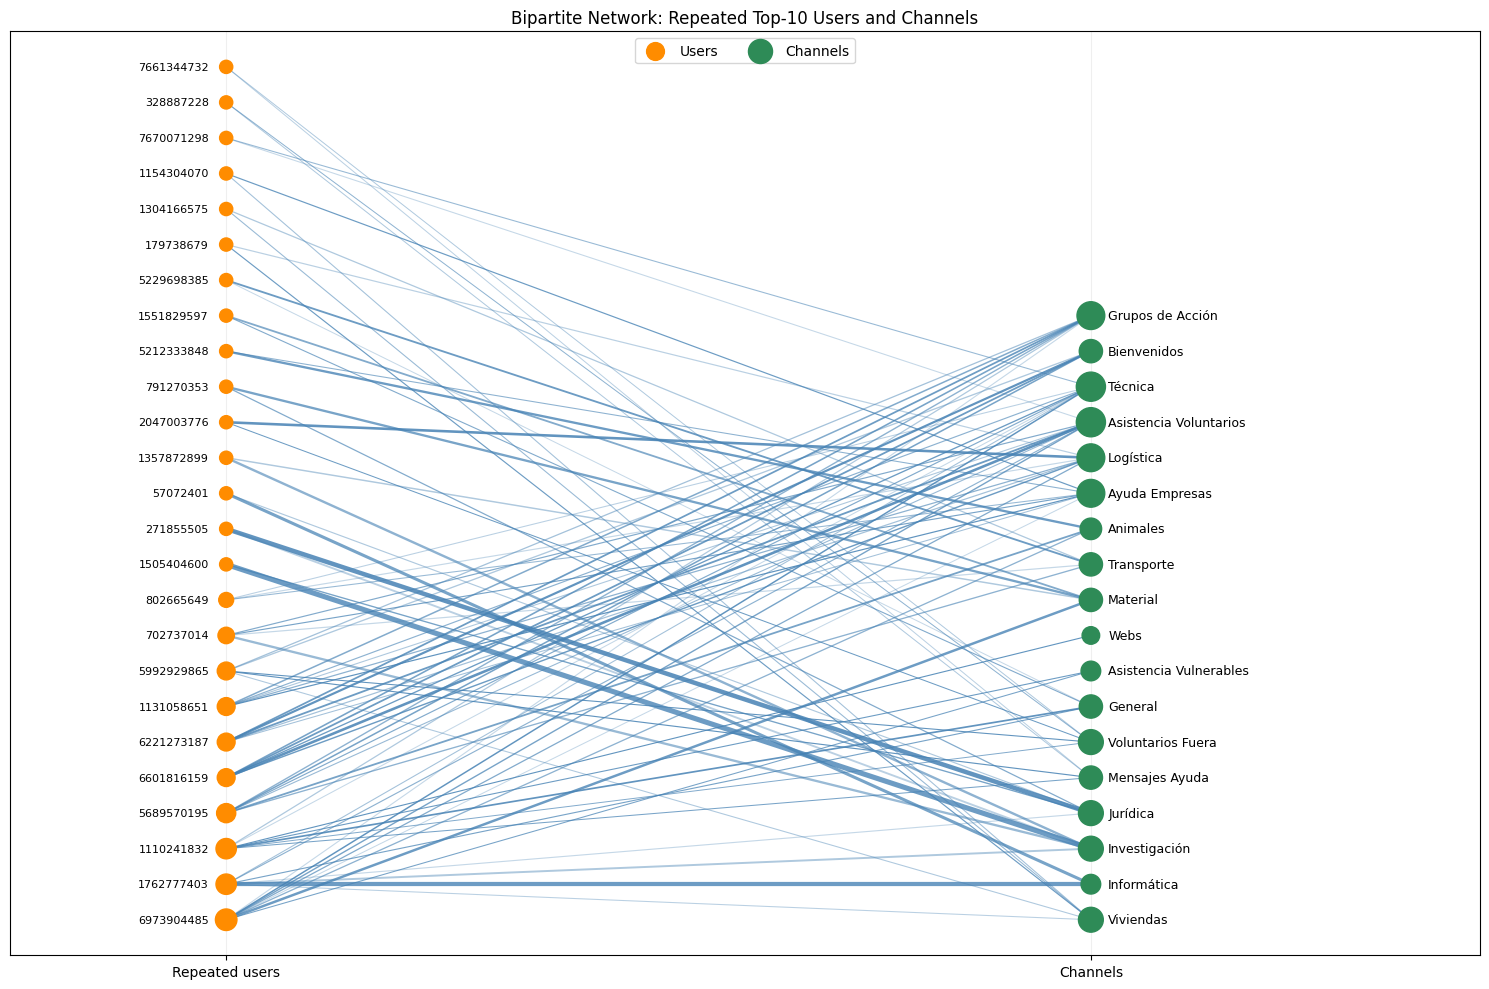

Channels ordered by similarity:
['Viviendas', 'Informática', 'Investigación', 'Jurídica', 'Mensajes Ayuda', 'Voluntarios Fuera', 'General', 'Asistencia Vulnerables', 'Webs', 'Material', 'Transporte', 'Animales', 'Ayuda Empresas', 'Logística', 'Asistencia Voluntarios', 'Técnica', 'Bienvenidos', 'Grupos de Acción']


In [13]:
# Sort channels by similarity, and add a user-channel network plot
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

# Rebuild top-users long table if needed
if 'top_users_long' not in locals():
    channel_top_users = {
        'General': top_users_general,
        'Bienvenidos': top_users_bienvenidos,
        'Transporte': top_users_tranporte,
        'Grupos de Acción': top_users_grupos_accion,
        'Jurídica': top_users_juridica,
        'Técnica': top_users_tecnica,
        'Animales': top_users_animales,
        'Informática': top_users_informatica,
        'Logística': top_users_logistica,
        'Ayuda Empresas': top_users_ayudaempresas,
        'Investigación': top_users_investigacion,
        'Asistencia Voluntarios': top_users_asistencia_voluntarios,
        'Asistencia Vulnerables': top_users_asistencia_vulnerables,
        'Material': top_users_material,
        'Webs': top_users_webs,
        'Mensajes Ayuda': top_users_mensajes_ayuda,
        'Voluntarios Fuera': top_users_voluntarios_fuera,
        'Viviendas': top_users_viviendas,
    }

    records = []
    for channel, series in channel_top_users.items():
        for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
            records.append({
                'channel': channel,
                'sender_id': int(sender_id),
                'rank': rank,
                'msg_count': int(msg_count)
            })
    top_users_long = pd.DataFrame(records)

# Presence matrix (binary membership in top-10)
presence = (
    top_users_long.assign(in_top10=1)
    .pivot_table(index='sender_id', columns='channel', values='in_top10', aggfunc='max', fill_value=0)
    .astype(int)
)

user_summary = (
    top_users_long.groupby('sender_id', as_index=True)
    .agg(n_channels=('channel', 'nunique'), total_top10_msgs=('msg_count', 'sum'))
    .sort_values(['n_channels', 'total_top10_msgs'], ascending=[False, False])
)

# Keep repeated users for readability
repeated_users = user_summary.index[user_summary['n_channels'] >= 2]
presence_rep = presence.loc[repeated_users]

if presence_rep.empty:
    print('No users appear in top-10 of more than one channel.')
else:
    # Channel ordering by similarity (Jaccard + hierarchical clustering)
    channel_matrix = presence_rep.T.values  # channels x users
    if presence_rep.shape[1] > 1 and presence_rep.shape[0] > 1:
        dist = pdist(channel_matrix, metric='jaccard')
        if np.all(np.isfinite(dist)) and dist.size > 0:
            Z = linkage(dist, method='average')
            ch_order_idx = leaves_list(Z)
            ordered_channels = presence_rep.columns[ch_order_idx]
        else:
            ordered_channels = presence_rep.columns
    else:
        ordered_channels = presence_rep.columns

    presence_sorted = presence_rep[ordered_channels]

    # --- Plot A: heatmap with sorted channels ---
    plt.figure(figsize=(14, 8))
    plt.imshow(presence_sorted.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.title('Top-10 User Overlap with Channels Sorted by Similarity')
    plt.xlabel('Channel (clustered by similar top-10 users)')
    plt.ylabel('Sender ID (users in >=2 channels)')
    plt.xticks(np.arange(presence_sorted.shape[1]), presence_sorted.columns, rotation=60, ha='right', fontsize=9)
    plt.yticks(np.arange(presence_sorted.shape[0]), [str(u) for u in presence_sorted.index], fontsize=8)
    cbar = plt.colorbar()
    cbar.set_label('In Top-10 (1=yes, 0=no)')
    plt.tight_layout()
    plt.show()

    # --- Plot B: bipartite network (users <-> channels) ---
    edges = top_users_long[top_users_long['sender_id'].isin(repeated_users)].copy()
    edges = edges[edges['channel'].isin(ordered_channels)].copy()

    user_order = list(user_summary.loc[repeated_users].index)
    channel_order = list(ordered_channels)

    user_y = {u: i for i, u in enumerate(user_order)}
    channel_y = {c: i for i, c in enumerate(channel_order)}

    fig, ax = plt.subplots(figsize=(15, 10))

    x_user = 0.0
    x_channel = 1.0

    # Draw edges (thicker = more messages; more opaque = better rank)
    msg_min = edges['msg_count'].min()
    msg_max = edges['msg_count'].max()
    msg_span = max(1, msg_max - msg_min)

    for _, row in edges.iterrows():
        u = int(row['sender_id'])
        c = row['channel']
        m = int(row['msg_count'])
        r = int(row['rank'])

        y1 = user_y[u]
        y2 = channel_y[c]

        lw = 0.7 + 3.0 * ((m - msg_min) / msg_span)
        alpha = 0.25 + 0.6 * ((11 - r) / 10.0)
        ax.plot([x_user, x_channel], [y1, y2], color='steelblue', linewidth=lw, alpha=alpha)

    # Draw user nodes
    user_sizes = [40 + 25 * user_summary.loc[u, 'n_channels'] for u in user_order]
    ax.scatter([x_user] * len(user_order), list(range(len(user_order))), s=user_sizes, color='darkorange', label='Users', zorder=3)

    # Draw channel nodes
    channel_degree = edges.groupby('channel')['sender_id'].nunique().reindex(channel_order).fillna(0)
    channel_sizes = [120 + 40 * channel_degree.loc[c] for c in channel_order]
    ax.scatter([x_channel] * len(channel_order), list(range(len(channel_order))), s=channel_sizes, color='seagreen', label='Channels', zorder=3)

    # Labels
    for u, y in user_y.items():
        ax.text(x_user - 0.02, y, str(u), ha='right', va='center', fontsize=8)

    for c, y in channel_y.items():
        ax.text(x_channel + 0.02, y, c, ha='left', va='center', fontsize=9)

    ax.set_xlim(-0.25, 1.45)
    ax.set_ylim(-1, max(len(user_order), len(channel_order)))
    ax.set_xticks([x_user, x_channel])
    ax.set_xticklabels(['Repeated users', 'Channels'])
    ax.set_yticks([])
    ax.set_title('Bipartite Network: Repeated Top-10 Users and Channels')
    ax.legend(loc='upper center', ncol=2)
    ax.grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.show()

    print('Channels ordered by similarity:')
    print(list(channel_order))

### Optimal channel clustering based on weighted top-10 users
This clustering analysis uses weighted top-10 user activity per channel and automatically selects the optimal number of clusters (instead of fixing it beforehand).

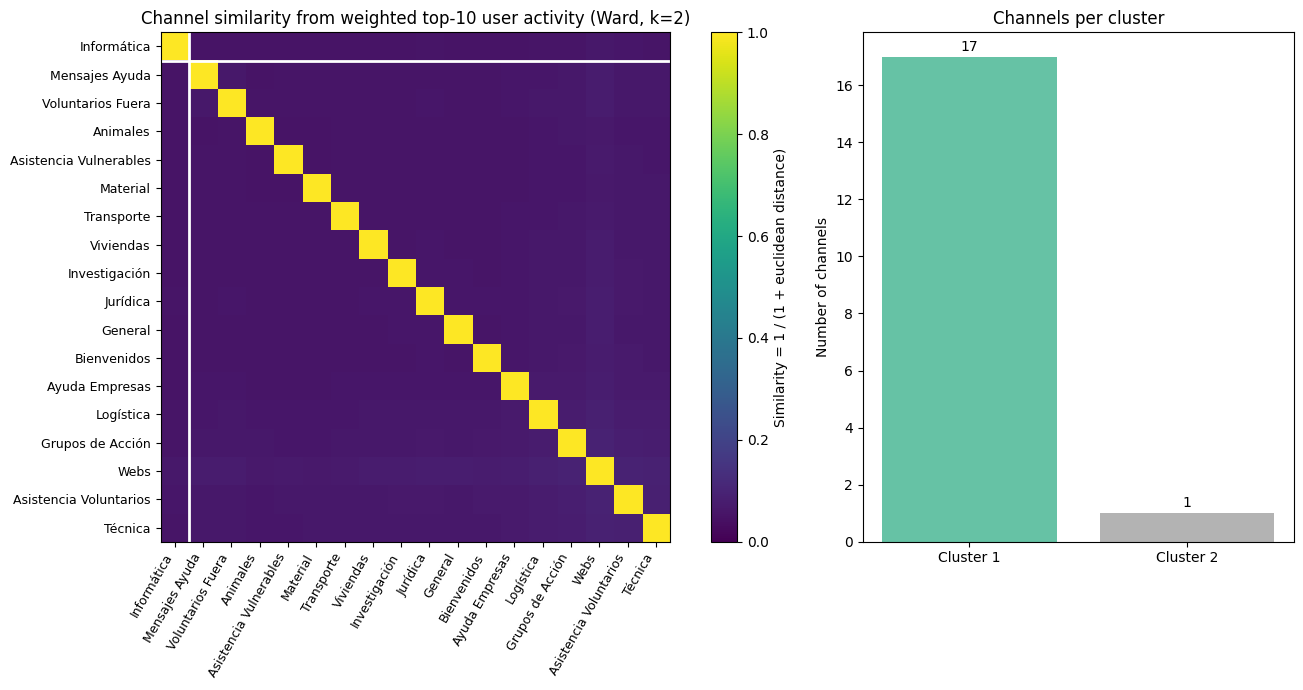

Optimal number of clusters selected: 2
Silhouette scores by candidate k:


,n_clusters,silhouette_score
0,2,0.127502
1,3,0.060074
2,4,0.062448
3,5,0.065005
4,6,0.067059
5,7,0.058745
6,8,0.043376



Cluster 1:
['Investigación', 'Material', 'Transporte', 'Jurídica', 'Animales', 'Bienvenidos', 'Grupos de Acción', 'Logística', 'Asistencia Voluntarios', 'Técnica', 'General', 'Viviendas', 'Ayuda Empresas', 'Asistencia Vulnerables', 'Mensajes Ayuda', 'Voluntarios Fuera', 'Webs']

Cluster 2:
['Informática']



,channel,cluster,weighted_top10_msgs,active_top10_users
0,Investigación,1,1431,10
1,Material,1,659,10
2,Transporte,1,492,10
3,Jurídica,1,459,10
4,Animales,1,423,10
5,Bienvenidos,1,387,10
6,Grupos de Acción,1,374,10
7,Logística,1,320,10
8,Asistencia Voluntarios,1,301,10
9,Técnica,1,162,10


In [14]:
# Cluster channels using weighted top-10 user activity and select optimal number of clusters
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

if 'top_users_long' not in locals():
    channel_top_users = {
        'General': top_users_general,
        'Bienvenidos': top_users_bienvenidos,
        'Transporte': top_users_tranporte,
        'Grupos de Acción': top_users_grupos_accion,
        'Jurídica': top_users_juridica,
        'Técnica': top_users_tecnica,
        'Animales': top_users_animales,
        'Informática': top_users_informatica,
        'Logística': top_users_logistica,
        'Ayuda Empresas': top_users_ayudaempresas,
        'Investigación': top_users_investigacion,
        'Asistencia Voluntarios': top_users_asistencia_voluntarios,
        'Asistencia Vulnerables': top_users_asistencia_vulnerables,
        'Material': top_users_material,
        'Webs': top_users_webs,
        'Mensajes Ayuda': top_users_mensajes_ayuda,
        'Voluntarios Fuera': top_users_voluntarios_fuera,
        'Viviendas': top_users_viviendas,
    }

    records = []
    for channel, series in channel_top_users.items():
        for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
            records.append({
                'channel': channel,
                'sender_id': int(sender_id),
                'rank': rank,
                'msg_count': int(msg_count)
            })
    top_users_long = pd.DataFrame(records)

# Weighted channel-user matrix using top-10 message counts per user (not only binary presence).
channel_user_weighted = (
    top_users_long
    .pivot_table(index='channel', columns='sender_id', values='msg_count', aggfunc='sum', fill_value=0)
    .astype(float)
)

if channel_user_weighted.shape[0] < 3:
    print('At least three channels are required to estimate an optimal number of clusters.')
else:
    channel_totals = channel_user_weighted.sum(axis=1)
    non_empty_channels = channel_totals[channel_totals > 0].index

    if len(non_empty_channels) < 3:
        print('At least three non-empty channels are required to estimate an optimal number of clusters.')
    else:
        channel_user_weighted = channel_user_weighted.loc[non_empty_channels]
        channel_totals = channel_user_weighted.sum(axis=1)

        # Normalize by channel total so weights represent user contribution structure.
        weighted_profiles = channel_user_weighted.div(channel_totals, axis=0).fillna(0.0)

        # Scale features before Ward linkage (euclidean-based) to avoid dominance by a few users.
        X = StandardScaler().fit_transform(weighted_profiles.values)

        if not np.all(np.isfinite(X)):
            print('The weighted profile matrix contains invalid values, so clustering could not be computed.')
        elif np.allclose(np.var(X, axis=0), 0):
            print('There is no variation across channels after weighting, so clustering would be arbitrary.')
        else:
            n_channels = X.shape[0]
            max_k = min(8, n_channels - 1)
            k_candidates = list(range(2, max_k + 1))

            silhouette_rows = []
            for k in k_candidates:
                model_k = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
                labels_k = model_k.fit_predict(X)
                score_k = silhouette_score(X, labels_k, metric='euclidean')
                silhouette_rows.append({'n_clusters': k, 'silhouette_score': score_k})

            silhouette_df = pd.DataFrame(silhouette_rows).sort_values('silhouette_score', ascending=False).reset_index(drop=True)
            best_k = int(silhouette_df.loc[0, 'n_clusters'])

            # Fit final model with the selected number of clusters.
            model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
            cluster_labels = model.fit_predict(X) + 1

            # Hierarchical ordering for visualization with Ward linkage.
            Z = linkage(X, method='ward', metric='euclidean')
            ch_order_idx = leaves_list(Z)
            ordered_channels = weighted_profiles.index[ch_order_idx]

            cluster_df_top10 = (
                pd.DataFrame({
                    'channel': weighted_profiles.index,
                    'cluster': cluster_labels,
                    'weighted_top10_msgs': channel_totals.values.astype(int),
                    'active_top10_users': (channel_user_weighted > 0).sum(axis=1).values.astype(int)
                })
                .sort_values(['cluster', 'weighted_top10_msgs', 'active_top10_users', 'channel'], ascending=[True, False, False, True])
                .reset_index(drop=True)
            )

            # Euclidean distance between weighted profiles; convert to bounded similarity for visualization.
            distance_matrix = squareform(pdist(X, metric='euclidean'))
            similarity_matrix = pd.DataFrame(
                1 / (1 + distance_matrix),
                index=weighted_profiles.index,
                columns=weighted_profiles.index
            )
            similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

            fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

            im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
            axes[0].set_title(f'Channel similarity from weighted top-10 user activity (Ward, k={best_k})')
            axes[0].set_xticks(np.arange(len(ordered_channels)))
            axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
            axes[0].set_yticks(np.arange(len(ordered_channels)))
            axes[0].set_yticklabels(ordered_channels, fontsize=9)
            cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cbar.set_label('Similarity = 1 / (1 + euclidean distance)')

            cluster_order = cluster_df_top10.set_index('channel').loc[ordered_channels, 'cluster'].values
            boundary_positions = np.where(cluster_order[:-1] != cluster_order[1:])[0] + 0.5
            for pos in boundary_positions:
                axes[0].axhline(pos, color='white', linewidth=2)
                axes[0].axvline(pos, color='white', linewidth=2)

            cluster_sizes = cluster_df_top10['cluster'].value_counts().sort_index()
            cluster_labels_plot = [f'Cluster {i}' for i in cluster_sizes.index]
            bar_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_sizes)))
            axes[1].bar(cluster_labels_plot, cluster_sizes.values, color=bar_colors)
            axes[1].set_title('Channels per cluster')
            axes[1].set_ylabel('Number of channels')
            for idx, count in enumerate(cluster_sizes.values):
                axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            print(f'Optimal number of clusters selected: {best_k}')
            print('Silhouette scores by candidate k:')
            display(silhouette_df.sort_values('n_clusters').reset_index(drop=True))
            print()

            for c in sorted(cluster_df_top10['cluster'].unique()):
                print(f'Cluster {c}:')
                print(cluster_df_top10.loc[cluster_df_top10['cluster'] == c, 'channel'].tolist())
                print()

            display(cluster_df_top10)

### Optimal channel clustering based on all users
This clustering analysis uses the full weighted distribution of messages per user in each channel and automatically selects the optimal number of clusters with hierarchical Ward clustering.

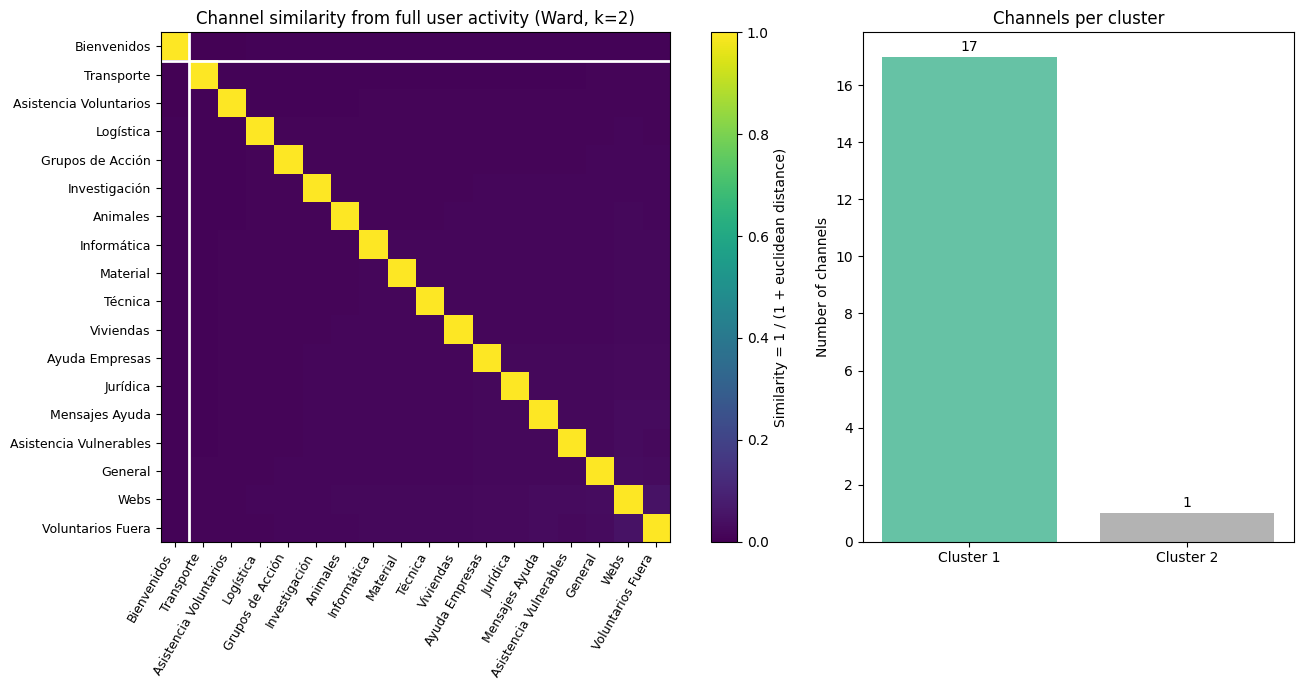

Optimal number of clusters selected: 2
Silhouette scores by candidate k:


,n_clusters,silhouette_score
0,2,0.461166
1,3,0.300781
2,4,0.264377
3,5,0.191728
4,6,0.159022
5,7,0.132837
6,8,0.115440



Cluster 1:
['Investigación', 'Transporte', 'Informática', 'Logística', 'Material', 'Asistencia Voluntarios', 'Grupos de Acción', 'Animales', 'Jurídica', 'Técnica', 'Viviendas', 'Ayuda Empresas', 'General', 'Mensajes Ayuda', 'Asistencia Vulnerables', 'Voluntarios Fuera', 'Webs']

Cluster 2:
['Bienvenidos']



,channel,cluster,total_messages,active_users
0,Investigación,1,2770,331
1,Transporte,1,2076,649
2,Informática,1,1964,234
3,Logística,1,1307,409
4,Material,1,1170,195
5,Asistencia Voluntarios,1,1163,434
6,Grupos de Acción,1,1052,340
7,Animales,1,1033,246
8,Jurídica,1,819,149
9,Técnica,1,488,187


In [15]:
# Cluster channels using full weighted user activity and select optimal number of clusters
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

channel_frames = {
    'General': df_general,
    'Bienvenidos': df_bienvenidos,
    'Transporte': df_tranporte,
    'Grupos de Acción': df_grupos_accion,
    'Jurídica': df_juridica,
    'Técnica': df_tecnica,
    'Animales': df_animales,
    'Informática': df_informatica,
    'Logística': df_logistica,
    'Ayuda Empresas': df_ayudaempresas,
    'Investigación': df_investigacion,
    'Asistencia Voluntarios': df_asistencia_voluntarios,
    'Asistencia Vulnerables': df_asistencia_vulnerables,
    'Material': df_material,
    'Webs': df_webs,
    'Mensajes Ayuda': df_mensajes_ayuda,
    'Voluntarios Fuera': df_voluntarios_fuera,
    'Viviendas': df_viviendas,
}

channel_activity = (
    pd.concat(
        [
            frame.groupby('sender_id').size().rename(channel_name)
            for channel_name, frame in channel_frames.items()
        ],
        axis=1
    )
    .T
    .fillna(0)
    .astype(float)
)

if channel_activity.shape[0] < 3:
    print('At least three channels are required to estimate an optimal number of clusters.')
else:
    channel_totals = channel_activity.sum(axis=1)
    non_empty_channels = channel_totals[channel_totals > 0].index

    if len(non_empty_channels) < 3:
        print('At least three non-empty channels are required to estimate an optimal number of clusters.')
    else:
        channel_activity = channel_activity.loc[non_empty_channels]
        channel_totals = channel_activity.sum(axis=1)
        active_users_per_channel = (channel_activity > 0).sum(axis=1)

        # Normalize within each channel so similarity reflects user participation structure, not channel size.
        activity_profiles = channel_activity.div(channel_totals, axis=0).fillna(0.0)

        # Scale features for Ward linkage (euclidean-based).
        X = StandardScaler().fit_transform(activity_profiles.values)

        if not np.all(np.isfinite(X)):
            print('The user-activity matrix contains invalid values, so clustering could not be computed.')
        elif np.allclose(np.var(X, axis=0), 0):
            print('There is no variation across channels, so clustering would be arbitrary.')
        else:
            n_channels = X.shape[0]
            max_k = min(8, n_channels - 1)
            k_candidates = list(range(2, max_k + 1))

            silhouette_rows = []
            for k in k_candidates:
                model_k = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
                labels_k = model_k.fit_predict(X)
                score_k = silhouette_score(X, labels_k, metric='euclidean')
                silhouette_rows.append({'n_clusters': k, 'silhouette_score': score_k})

            silhouette_df = pd.DataFrame(silhouette_rows).sort_values('silhouette_score', ascending=False).reset_index(drop=True)
            best_k = int(silhouette_df.loc[0, 'n_clusters'])

            model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
            cluster_labels = model.fit_predict(X) + 1

            Z = linkage(X, method='ward', metric='euclidean')
            ch_order_idx = leaves_list(Z)
            ordered_channels = channel_activity.index[ch_order_idx]

            cluster_df = (
                pd.DataFrame({
                    'channel': channel_activity.index,
                    'cluster': cluster_labels,
                    'total_messages': channel_totals.values.astype(int),
                    'active_users': active_users_per_channel.values.astype(int)
                })
                .sort_values(['cluster', 'total_messages', 'active_users', 'channel'], ascending=[True, False, False, True])
                .reset_index(drop=True)
            )

            distance_matrix = squareform(pdist(X, metric='euclidean'))
            similarity_matrix = pd.DataFrame(
                1 / (1 + distance_matrix),
                index=channel_activity.index,
                columns=channel_activity.index
            )
            similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

            fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

            im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
            axes[0].set_title(f'Channel similarity from full user activity (Ward, k={best_k})')
            axes[0].set_xticks(np.arange(len(ordered_channels)))
            axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
            axes[0].set_yticks(np.arange(len(ordered_channels)))
            axes[0].set_yticklabels(ordered_channels, fontsize=9)
            cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cbar.set_label('Similarity = 1 / (1 + euclidean distance)')

            cluster_order = cluster_df.set_index('channel').loc[ordered_channels, 'cluster'].values
            boundary_positions = np.where(cluster_order[:-1] != cluster_order[1:])[0] + 0.5
            for pos in boundary_positions:
                axes[0].axhline(pos, color='white', linewidth=2)
                axes[0].axvline(pos, color='white', linewidth=2)

            cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
            cluster_labels_plot = [f'Cluster {i}' for i in cluster_sizes.index]
            bar_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_sizes)))
            axes[1].bar(cluster_labels_plot, cluster_sizes.values, color=bar_colors)
            axes[1].set_title('Channels per cluster')
            axes[1].set_ylabel('Number of channels')
            for idx, count in enumerate(cluster_sizes.values):
                axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            print(f'Optimal number of clusters selected: {best_k}')
            print('Silhouette scores by candidate k:')
            display(silhouette_df.sort_values('n_clusters').reset_index(drop=True))
            print()

            for c in sorted(cluster_df['cluster'].unique()):
                print(f'Cluster {c}:')
                print(cluster_df.loc[cluster_df['cluster'] == c, 'channel'].tolist())
                print()

            display(cluster_df)

### Optimal Clusters (alternative view)
This alternative clustering view also uses the full weighted user activity and selects the optimal number of clusters automatically, so results are data-driven instead of fixed to 4 clusters.

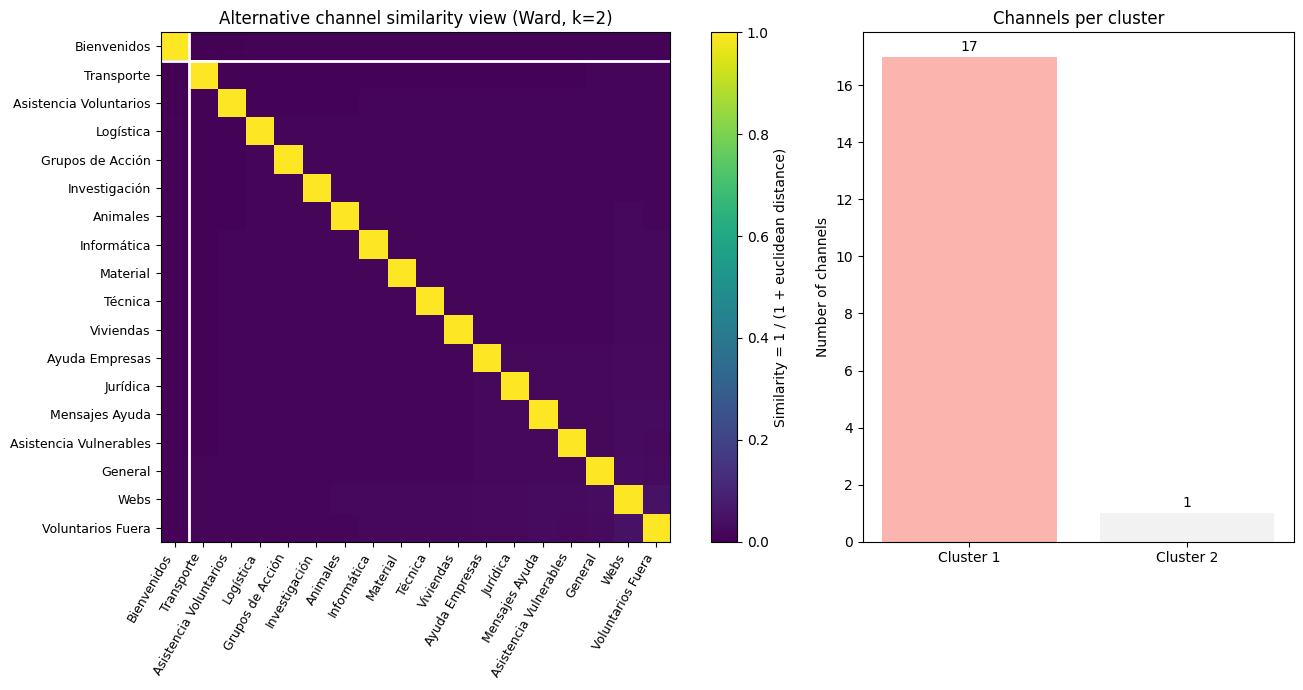

Optimal number of clusters selected: 2
Silhouette scores by candidate k:


,n_clusters,silhouette_score
0,2,0.461166
1,3,0.300781
2,4,0.264377
3,5,0.191728
4,6,0.159022
5,7,0.132837
6,8,0.115440



Cluster 1:
['Investigación', 'Transporte', 'Informática', 'Logística', 'Material', 'Asistencia Voluntarios', 'Grupos de Acción', 'Animales', 'Jurídica', 'Técnica', 'Viviendas', 'Ayuda Empresas', 'General', 'Mensajes Ayuda', 'Asistencia Vulnerables', 'Voluntarios Fuera', 'Webs']

Cluster 2:
['Bienvenidos']



,channel,cluster,total_messages,active_users
0,Investigación,1,2770,331
1,Transporte,1,2076,649
2,Informática,1,1964,234
3,Logística,1,1307,409
4,Material,1,1170,195
5,Asistencia Voluntarios,1,1163,434
6,Grupos de Acción,1,1052,340
7,Animales,1,1033,246
8,Jurídica,1,819,149
9,Técnica,1,488,187


In [16]:
# Alternative run: full weighted user activity with automatic optimal-k Ward clustering
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

channel_frames = {
    'General': df_general,
    'Bienvenidos': df_bienvenidos,
    'Transporte': df_tranporte,
    'Grupos de Acción': df_grupos_accion,
    'Jurídica': df_juridica,
    'Técnica': df_tecnica,
    'Animales': df_animales,
    'Informática': df_informatica,
    'Logística': df_logistica,
    'Ayuda Empresas': df_ayudaempresas,
    'Investigación': df_investigacion,
    'Asistencia Voluntarios': df_asistencia_voluntarios,
    'Asistencia Vulnerables': df_asistencia_vulnerables,
    'Material': df_material,
    'Webs': df_webs,
    'Mensajes Ayuda': df_mensajes_ayuda,
    'Voluntarios Fuera': df_voluntarios_fuera,
    'Viviendas': df_viviendas,
}

channel_activity = (
    pd.concat(
        [
            frame.groupby('sender_id').size().rename(channel_name)
            for channel_name, frame in channel_frames.items()
        ],
        axis=1
    )
    .T
    .fillna(0)
    .astype(float)
)

if channel_activity.shape[0] < 3:
    print('At least three channels are required to estimate an optimal number of clusters.')
else:
    channel_totals = channel_activity.sum(axis=1)
    non_empty_channels = channel_totals[channel_totals > 0].index

    if len(non_empty_channels) < 3:
        print('At least three non-empty channels are required to estimate an optimal number of clusters.')
    else:
        channel_activity = channel_activity.loc[non_empty_channels]
        channel_totals = channel_activity.sum(axis=1)
        active_users_per_channel = (channel_activity > 0).sum(axis=1)

        activity_profiles = channel_activity.div(channel_totals, axis=0).fillna(0.0)
        X = StandardScaler().fit_transform(activity_profiles.values)

        if not np.all(np.isfinite(X)):
            print('The user-activity matrix contains invalid values, so clustering could not be computed.')
        elif np.allclose(np.var(X, axis=0), 0):
            print('There is no variation across channels, so clustering would be arbitrary.')
        else:
            n_channels = X.shape[0]
            max_k = min(8, n_channels - 1)
            k_candidates = list(range(2, max_k + 1))

            silhouette_rows = []
            for k in k_candidates:
                model_k = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
                labels_k = model_k.fit_predict(X)
                score_k = silhouette_score(X, labels_k, metric='euclidean')
                silhouette_rows.append({'n_clusters': k, 'silhouette_score': score_k})

            silhouette_df = pd.DataFrame(silhouette_rows).sort_values('silhouette_score', ascending=False).reset_index(drop=True)
            best_k = int(silhouette_df.loc[0, 'n_clusters'])

            model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
            cluster_labels = model.fit_predict(X) + 1

            Z = linkage(X, method='ward', metric='euclidean')
            ch_order_idx = leaves_list(Z)
            ordered_channels = channel_activity.index[ch_order_idx]

            cluster_df = (
                pd.DataFrame({
                    'channel': channel_activity.index,
                    'cluster': cluster_labels,
                    'total_messages': channel_totals.values.astype(int),
                    'active_users': active_users_per_channel.values.astype(int)
                })
                .sort_values(['cluster', 'total_messages', 'active_users', 'channel'], ascending=[True, False, False, True])
                .reset_index(drop=True)
            )

            distance_matrix = squareform(pdist(X, metric='euclidean'))
            similarity_matrix = pd.DataFrame(
                1 / (1 + distance_matrix),
                index=channel_activity.index,
                columns=channel_activity.index
            )
            similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

            fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

            im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
            axes[0].set_title(f'Alternative channel similarity view (Ward, k={best_k})')
            axes[0].set_xticks(np.arange(len(ordered_channels)))
            axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
            axes[0].set_yticks(np.arange(len(ordered_channels)))
            axes[0].set_yticklabels(ordered_channels, fontsize=9)
            cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cbar.set_label('Similarity = 1 / (1 + euclidean distance)')

            cluster_order = cluster_df.set_index('channel').loc[ordered_channels, 'cluster'].values
            boundary_positions = np.where(cluster_order[:-1] != cluster_order[1:])[0] + 0.5
            for pos in boundary_positions:
                axes[0].axhline(pos, color='white', linewidth=2)
                axes[0].axvline(pos, color='white', linewidth=2)

            cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
            cluster_labels_plot = [f'Cluster {i}' for i in cluster_sizes.index]
            bar_colors = plt.cm.Pastel1(np.linspace(0, 1, len(cluster_sizes)))
            axes[1].bar(cluster_labels_plot, cluster_sizes.values, color=bar_colors)
            axes[1].set_title('Channels per cluster')
            axes[1].set_ylabel('Number of channels')
            for idx, count in enumerate(cluster_sizes.values):
                axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            print(f'Optimal number of clusters selected: {best_k}')
            print('Silhouette scores by candidate k:')
            display(silhouette_df.sort_values('n_clusters').reset_index(drop=True))
            print()

            for c in sorted(cluster_df['cluster'].unique()):
                print(f'Cluster {c}:')
                print(cluster_df.loc[cluster_df['cluster'] == c, 'channel'].tolist())
                print()

            display(cluster_df)

### Clustering tree.